In [3]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [10]:
using StatsBase

In [11]:
using GLM

# Camp fixe, canvi v

In [27]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :active => Bool,

        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        r = sqrt((x)^2 + (y)^2)
        ll = sqrt(DMedium / delta)

        # evitar singularidad en r=0
        r_eff = max(r, 1e-3)

        mm = 1.0 * besselk(0, r_eff / ll)

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) 

        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	G (Float64 agent)
	vy (Float64 agent)
	S (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
            v_tumble
        end
    Dr_tumble = 6.2
    Dr_total = if a

In [4]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [46]:
com = Community(
    fixed_source,
    N=500,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 100.0    #Velocitat bacteries biològica
# com.v = 80.0
# com.v = 75.0  #Velocitat bacteries biològica
com.v = 60.0
# com.v = 50.0
# com.v = 20.0
# com.v = 10.0
# com.v = 5.0

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 5
com.delta = 0.0002

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.x = 2.5*sqrt(com.DMedium/com.delta)
com.y = 2.5*sqrt(com.DMedium/com.delta)
# com.x = 40
# com.y = 40
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 


500-element Vector{Bool}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1

In [47]:
outfile = "fsb_eff_v60.jld2"
steps = 60000

loadToPlatform!(com, preallocateAgents=500)

jldopen(outfile, "w") do file

    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
    end
end


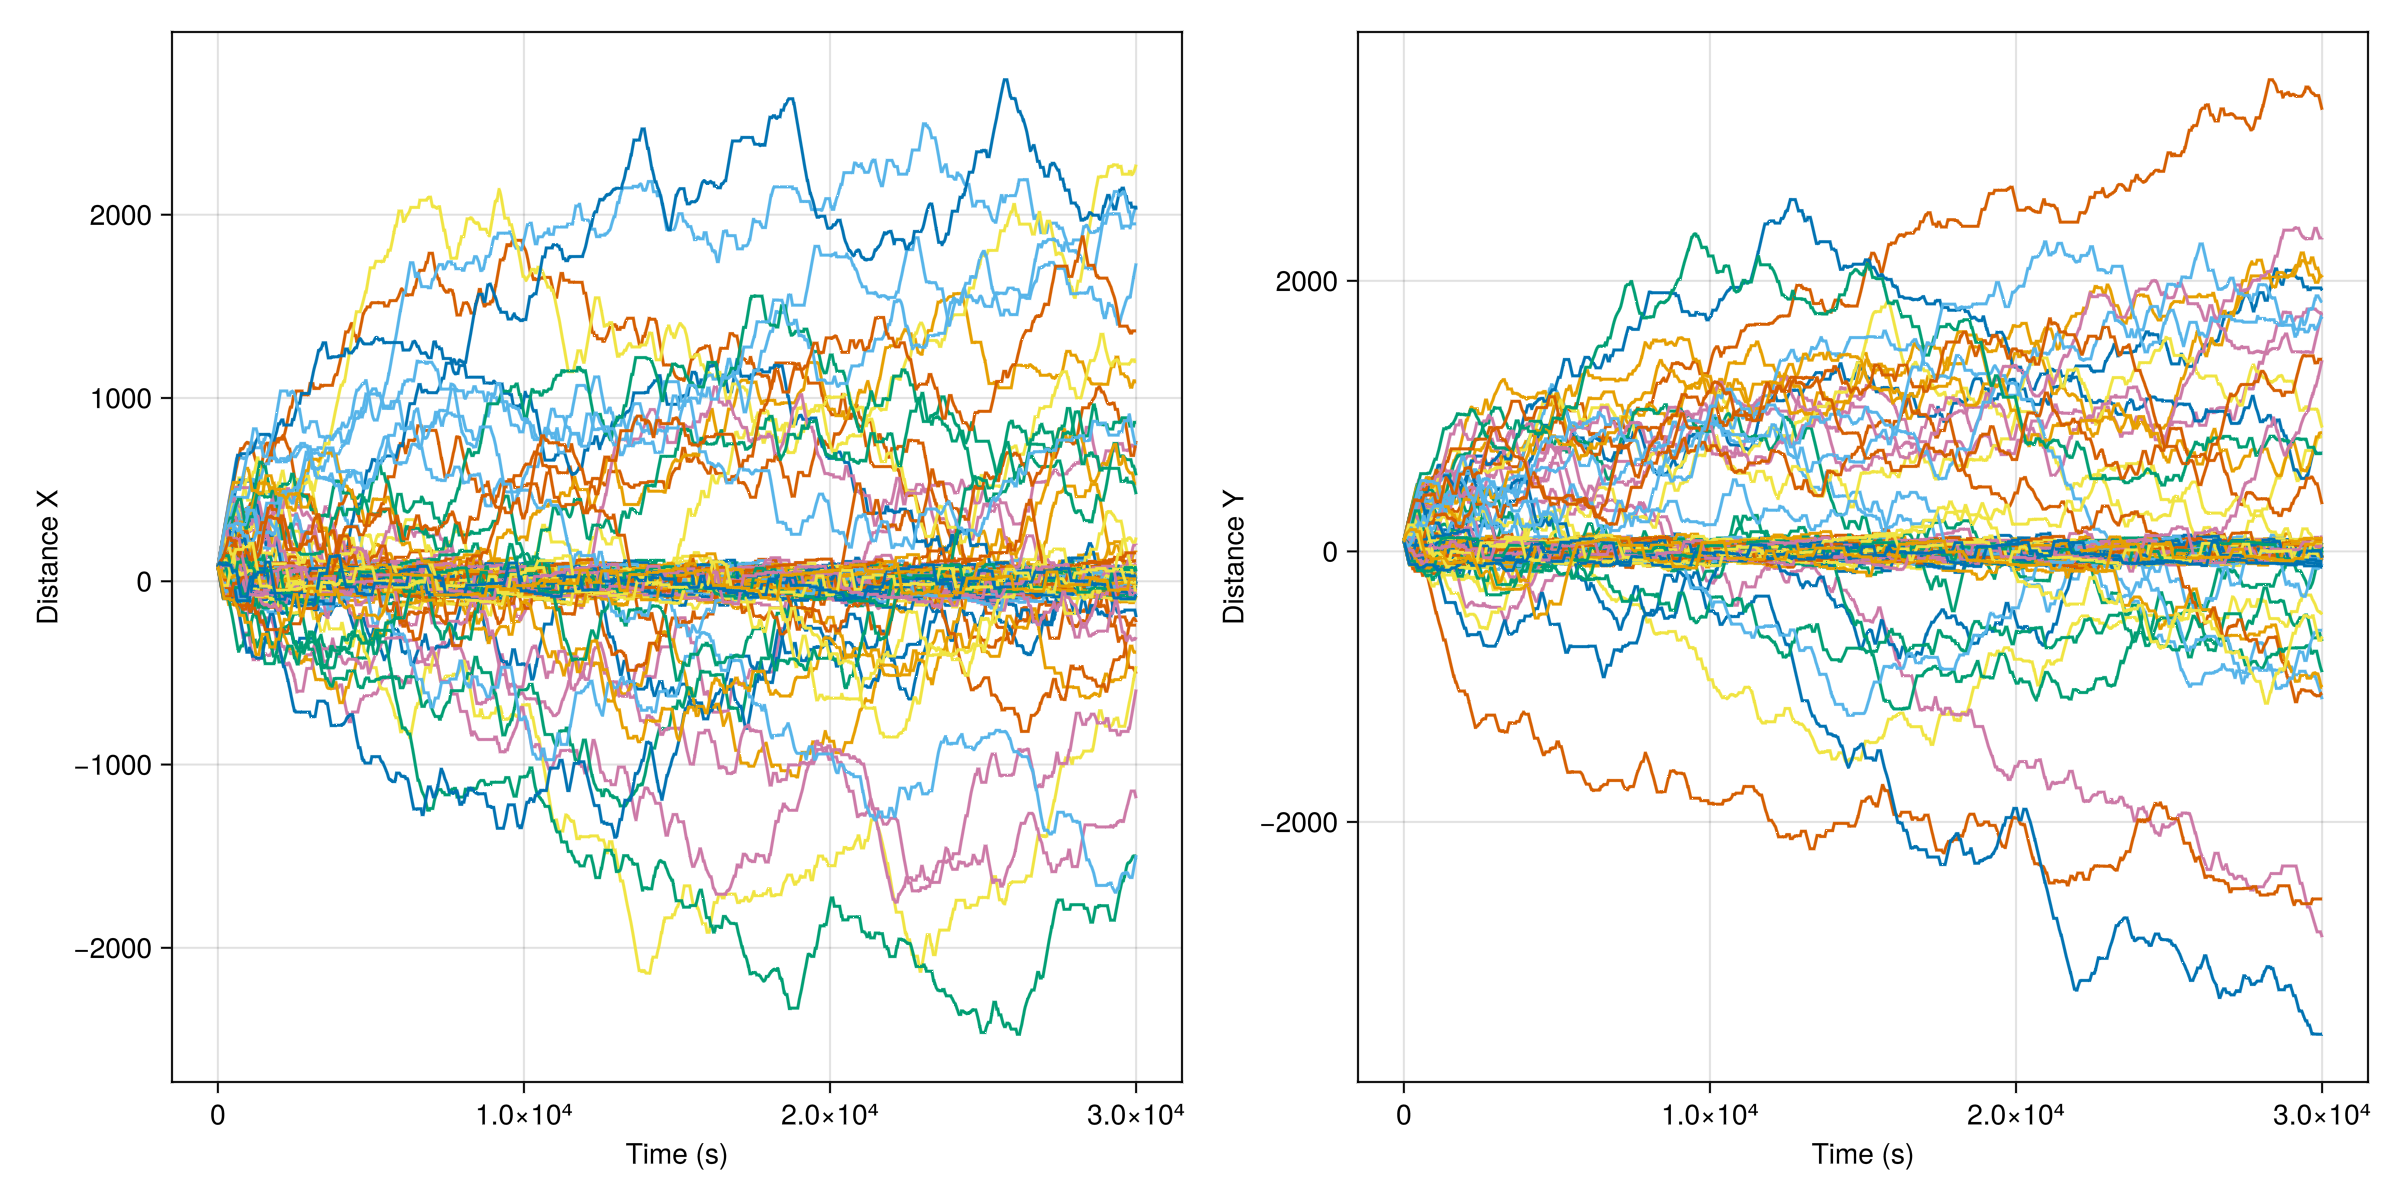

GLMakie.Screen(...)

In [ ]:
fig3 = Figure(size=(1200, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Distance X")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Distance Y")

steps = 30000

jldopen("fsb_eff_v10.jld2", "r") do file 
    for agent in 1:100
        x = Float64[] 
        y = Float64[]

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            src = 1

            xs = 0
            ys = 0

            x_1 = g["x"][agent]
            y_1 = g["y"][agent]

            # dist = abs(sqrt((x_1 - xs)^2 + (y_1 - ys)^2))
            dist = x_1 - xs
            dist_2 = y_1 - ys

            push!(x, dist)
            push!(y, dist_2)
    

        end

        # lines!(ax1, 1:steps, log.(x))
        lines!(ax1, 1:steps, x)
        lines!(ax2, 1:steps, y)
        
    end

end
display(fig3)

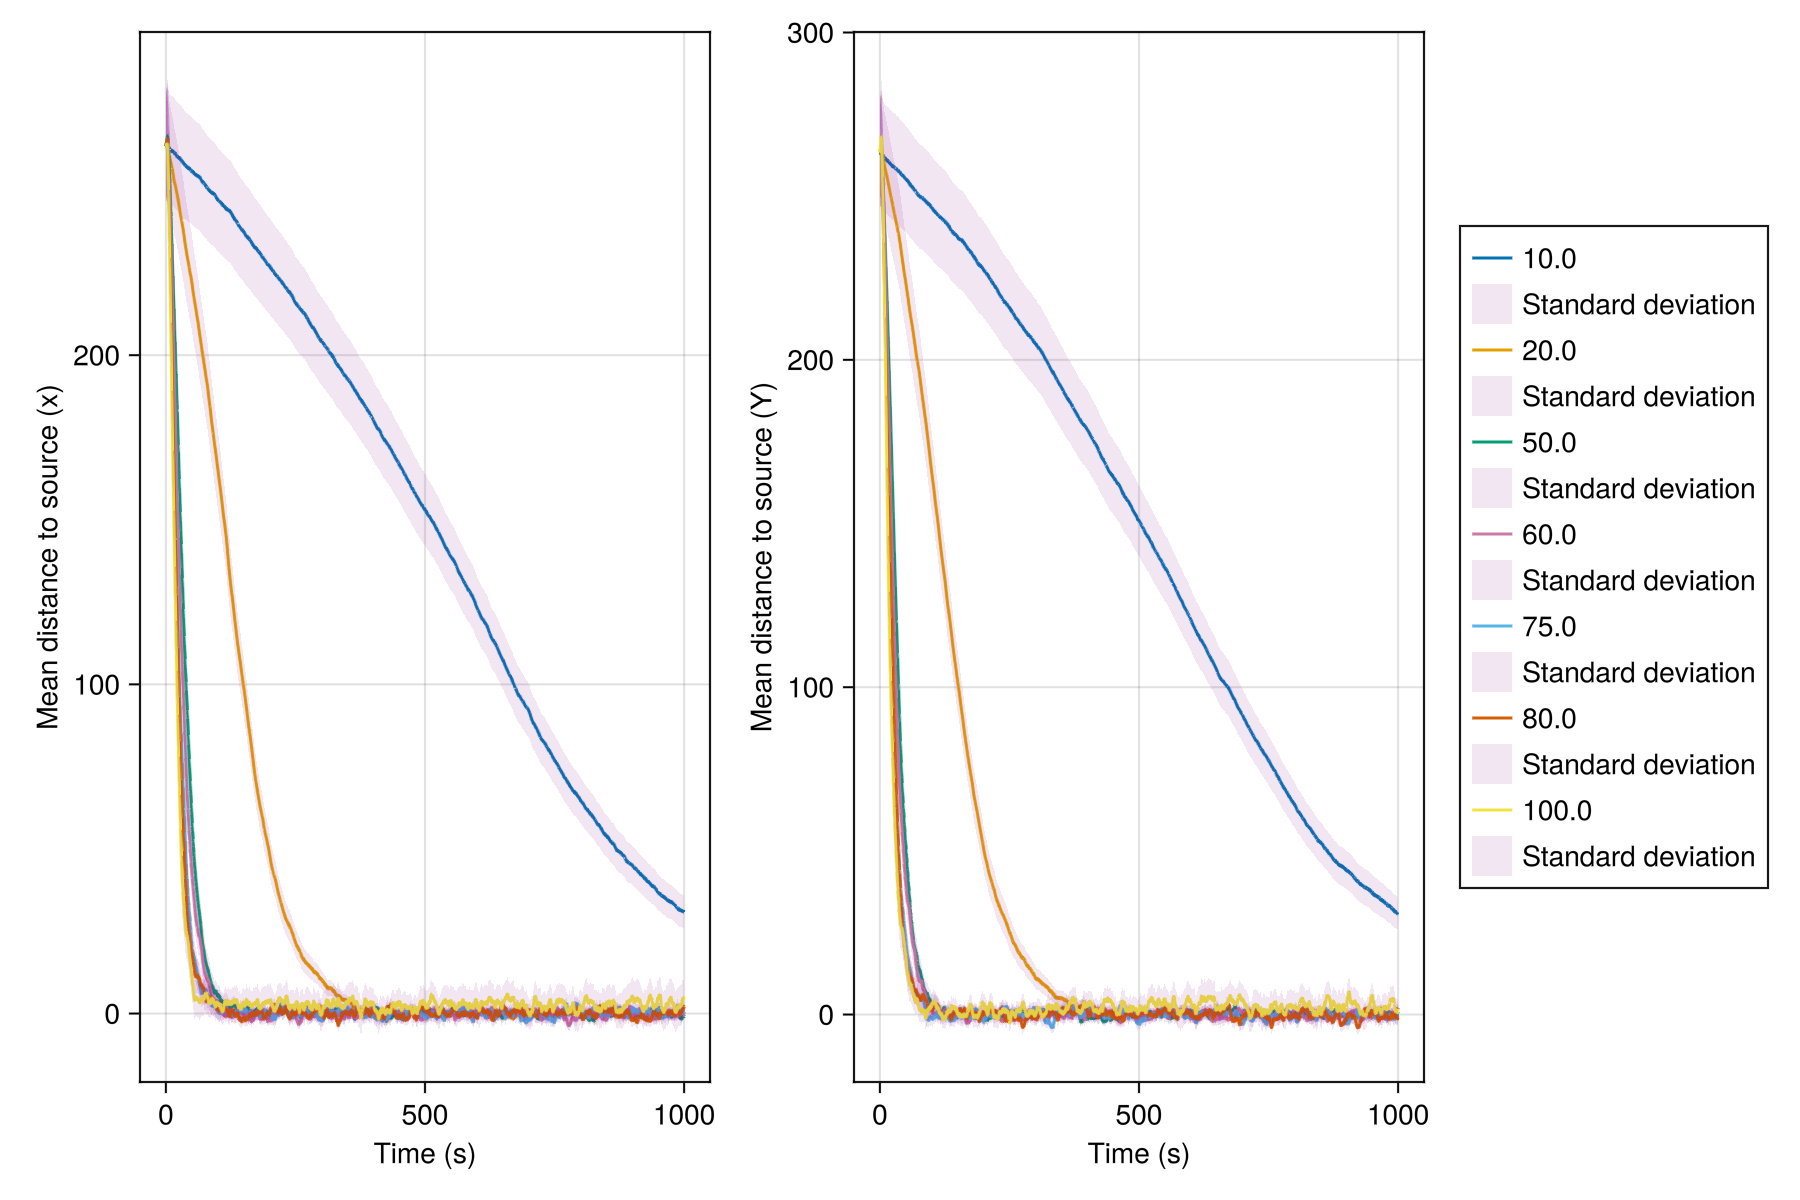

GLMakie.Screen(...)

In [16]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 100000

v = [10.0, 20.0, 50.0, 60.0, 75.0, 80.0, 100]

for i in 1:length(v)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v$(v[i])_l316_D.jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(v[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 

    end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

In [45]:
save("Plots/Fixed_source_model/Next/l_fix_v_dif.png", fig3)

## Extract trajectories

In [23]:
dfs_l316 = Dict{Int64, DataFrame}()


vel_1 = [10.0, 20.0, 50.0, 60.0, 75.0, 80.0, 100.0]
# vel_1 = [60, 80]
N_agents = 500
end_step = 60000

for (v_idx, v) in enumerate(vel_1)

    filename = @sprintf("fsb_v%s_l316_D.jld2", v)
    println("Processing $filename")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
    steps_vec = Int[]
    agents_vec = Int[]
    x_vec = Float64[]
    y_vec = Float64[]
        
    jldopen(filename, "r") do file
        for agent in 1:500
            for step in 1:10:end_step
                g = file[@sprintf("step_%06d", step)]

                push!(steps_vec, step)
                push!(agents_vec, agent)
                push!(x_vec, g["x"][agent])
                push!(y_vec, g["y"][agent])
            end
        end
    end

    df = DataFrame(
        step = steps_vec,
        agent = agents_vec,
        x = x_vec,
        y = y_vec
    )

        # store in dict
    dfs_l316[v] = df

end

Processing fsb_v10.0_l316_D.jld2
Processing fsb_v20.0_l316_D.jld2
Processing fsb_v50.0_l316_D.jld2
Processing fsb_v60.0_l316_D.jld2
Processing fsb_v75.0_l316_D.jld2
Processing fsb_v80.0_l316_D.jld2
Processing fsb_v100.0_l316_D.jld2


In [7]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

In [19]:
times = zeros(6, 3)
times[:, 1] = [20, 50, 60, 75, 80, 100]
times[:, 2] = [40000, 20000, 20000, 20000, 20000, 20000]
times[:, 3] = [200, 200, 100, 100, 100, 100]

6-element Vector{Int64}:
 200
 200
 100
 100
 100
 100

In [48]:
# metrics_l316 = DataFrame(
#     v = Int64[],
#     mu_x = Float64[],
#     mu_y = Float64[],
#     sigma = Float64[],
#     k = Float64[],
#     D = Float64[]
# )

# vel_1 = [10, 20, 50, 60, 75, 80, 100]
vel_1 = [100]

for i in 1
    df = dfs_l316[vel_1[i]]

    eq_step = times[2, 2]
    eq_step_2 = times[i, 3]

    eq = df[df.step .>= eq_step, :]

    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)

    sigma = (sigma_x + sigma_y) / 2

    grouped_ag = groupby(eq, :agent)
    lags = (1:50:eq_step)

    correlations = zeros(length(grouped_ag), length(lags))
    correlations_y = zeros(length(grouped_ag), length(lags))

    for i in 1:length(grouped_ag)
        df_ag = grouped_ag[i]
        traj = df_ag.x
        traj_y = df_ag.y
        cor = autocor(traj, lags; demean = false)
        cor_y = autocor(traj_y, lags; demean = false)
        correlations[i, :] = cor
        correlations_y[i, :] = cor_y
    end

    correlations_mean = Float64[]
    correlations_mean_y = Float64[]

    for i in 1:length(lags)
        lag_mean = correlations[:, i]
        lag_mean_y = correlations_y[:, i]
        push!(correlations_mean, mean(lag_mean))
        push!(correlations_mean_y, mean(lag_mean_y))
    end

    logx = log.(abs.(correlations_mean))
    logy = log.(abs.(correlations_mean_y))

    slope_x, intercept_x = linear_fit(lags, logx)
    slope_y, intercept_y = linear_fit(lags, logy)
    k_x = -slope_x 
    k_y = -slope_y

    k = (k_x + k_y) / 2
    D = sigma^2 * k

    push!(metrics_l316, (
        vel_1[i],
        mu_x,
        mu_y,
        sigma,
        k,
        D
    ))
end

MethodError: MethodError: no method matching autocor(::SubArray{Float64, 1, Vector{Float64}, Tuple{Vector{Int64}}, false}, ::StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}; demean::Bool)

Closest candidates are:
  autocor(::AbstractVecOrMat{<:Real}; demean)
   @ StatsBase C:\Users\ibzja\.julia\packages\StatsBase\5D4Dh\src\signalcorr.jl:204
  autocor(::AbstractVector{<:Real}, !Matched::AbstractVector{<:Integer}; demean)
   @ StatsBase C:\Users\ibzja\.julia\packages\StatsBase\5D4Dh\src\signalcorr.jl:194


In [44]:
metrics_l316

Row,v,mu_x,mu_y,sigma,k,D
,Int64,Float64,Float64,Float64,Float64,Float64
1,20,1.42387,1.66792,41.152,0.0111978,18.9634
2,50,0.719602,-0.176098,55.9187,0.0168926,52.8214
3,60,-0.240256,0.170481,64.8118,0.0169979,71.4007
4,75,-0.0564657,0.243,76.114,0.0175203,101.501
5,80,0.374778,0.77169,79.534,0.0177405,112.22
6,100,7.29692,5.83898,166.531,0.0180303,500.027


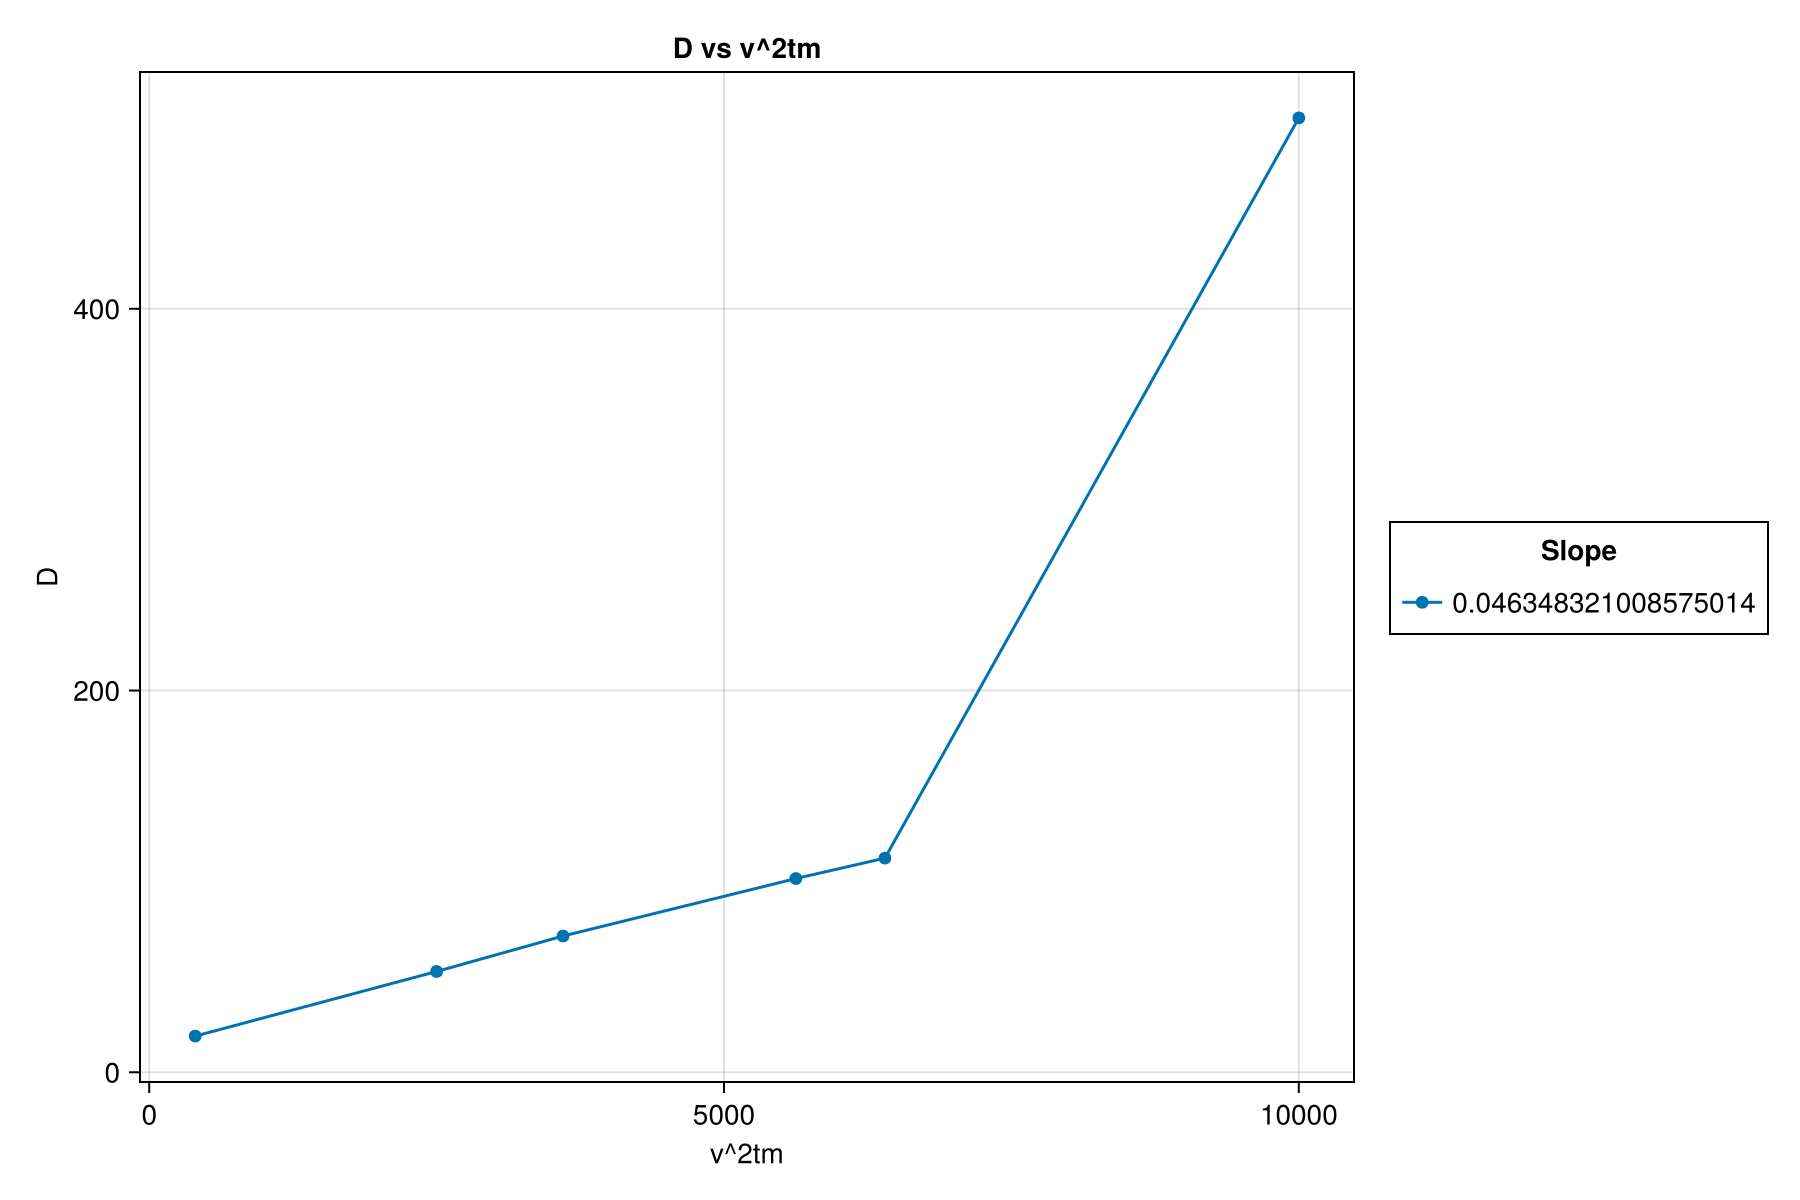

In [46]:
using CairoMakie
velocities = [20, 50, 60, 75, 80, 100]
diff = Float64[]
vtm = Float64[]

fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "D vs v^2tm", xlabel = "v^2tm", ylabel = "D")

diff = Float64[]
vtm = Float64[]
for (idx, v) in enumerate(velocities)
    mask = (metrics_l316.v .== v)
    row = metrics_l316.D[mask]
    D = row[1]
    valor = v^2
    push!(diff, D)
    push!(vtm, valor)

end
df = DataFrame(x = vtm, y = diff)
model = lm(@formula(y ~ x), df)

a = coef(model)[2]   # slope
b = coef(model)[1]

scatterlines!(ax, vtm, diff, label = "$a")
fig[1,2] = Legend(fig, ax, "Slope")
fig

In [47]:
save("Plots/Fixed_source_model/Next/l_316_Dvtm.svg", fig)

CairoMakie.Screen{SVG}


# Lambdas petites - k fit

Lambdas: 0.025 era sa mes petita
Probam: 0.2, 0.1, 0.05, 0.025, 0.0125 (5 lambdas)
Velocitats de sempre = 5, 10, 20, 100
20 simulations - o fes 2 velocitats = 10 simulacions x 1.5 min = 15 min. 

In [6]:
ns = [0.0125, 0.025, 0.05, 0.1, 0.2]
steps = 60000
vel = [10.0, 100.0]


for n in ns
    for (idx, v) in enumerate(vel)
        println("Running n=$n")

        com = Community(
            fixed_source,
            N=500,
            dt=0.01,
            simBox = [-100.0 100.0; -100.0 100.0],
            NMedium = [100, 100]
        )   

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = v 

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1  

        com.α   = 6.0

        com.K = 2.0 

        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.1

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        Dc = 10 
        delta = 0.01

        d = delta/((v/10)^2)

        #Canviar lambda

        com.DMedium = Dc / n
        com.delta = d * n

        com.x = 2.5*sqrt(com.DMedium/com.delta)
        com.y = 2.5*sqrt(com.DMedium/com.delta)
        com.theta = rand(Uniform(0,2π),com.N)

        com.methyl .= 0.0
        com.Yp .= com.K


        loadToPlatform!(com, preallocateAgents=1000)
        
        outfile = @sprintf("fsb_v%s_l%s_k.jld2", v, n)  ###CANVIARRR NOOM

        jldopen(outfile, "w") do file

            meta = JLD2.Group(file, "meta")
            meta["DMedium"] = com.DMedium
            meta["delta"] = com.delta

            for step in 1:steps
                CellBasedModels.step!(com)

                stepname = @sprintf("step_%06d", step)
                g = JLD2.Group(file, stepname)

                # Agent-level arrays (length = N)
                g["x"] = copy(com.x)
                g["y"] = copy(com.y)
                g["theta"] = copy(com.theta)

    
            end
        end
    end
end

Running n=0.0125
Running n=0.0125
Running n=0.025
Running n=0.025
Running n=0.05
Running n=0.05
Running n=0.1
Running n=0.1
Running n=0.2
Running n=0.2


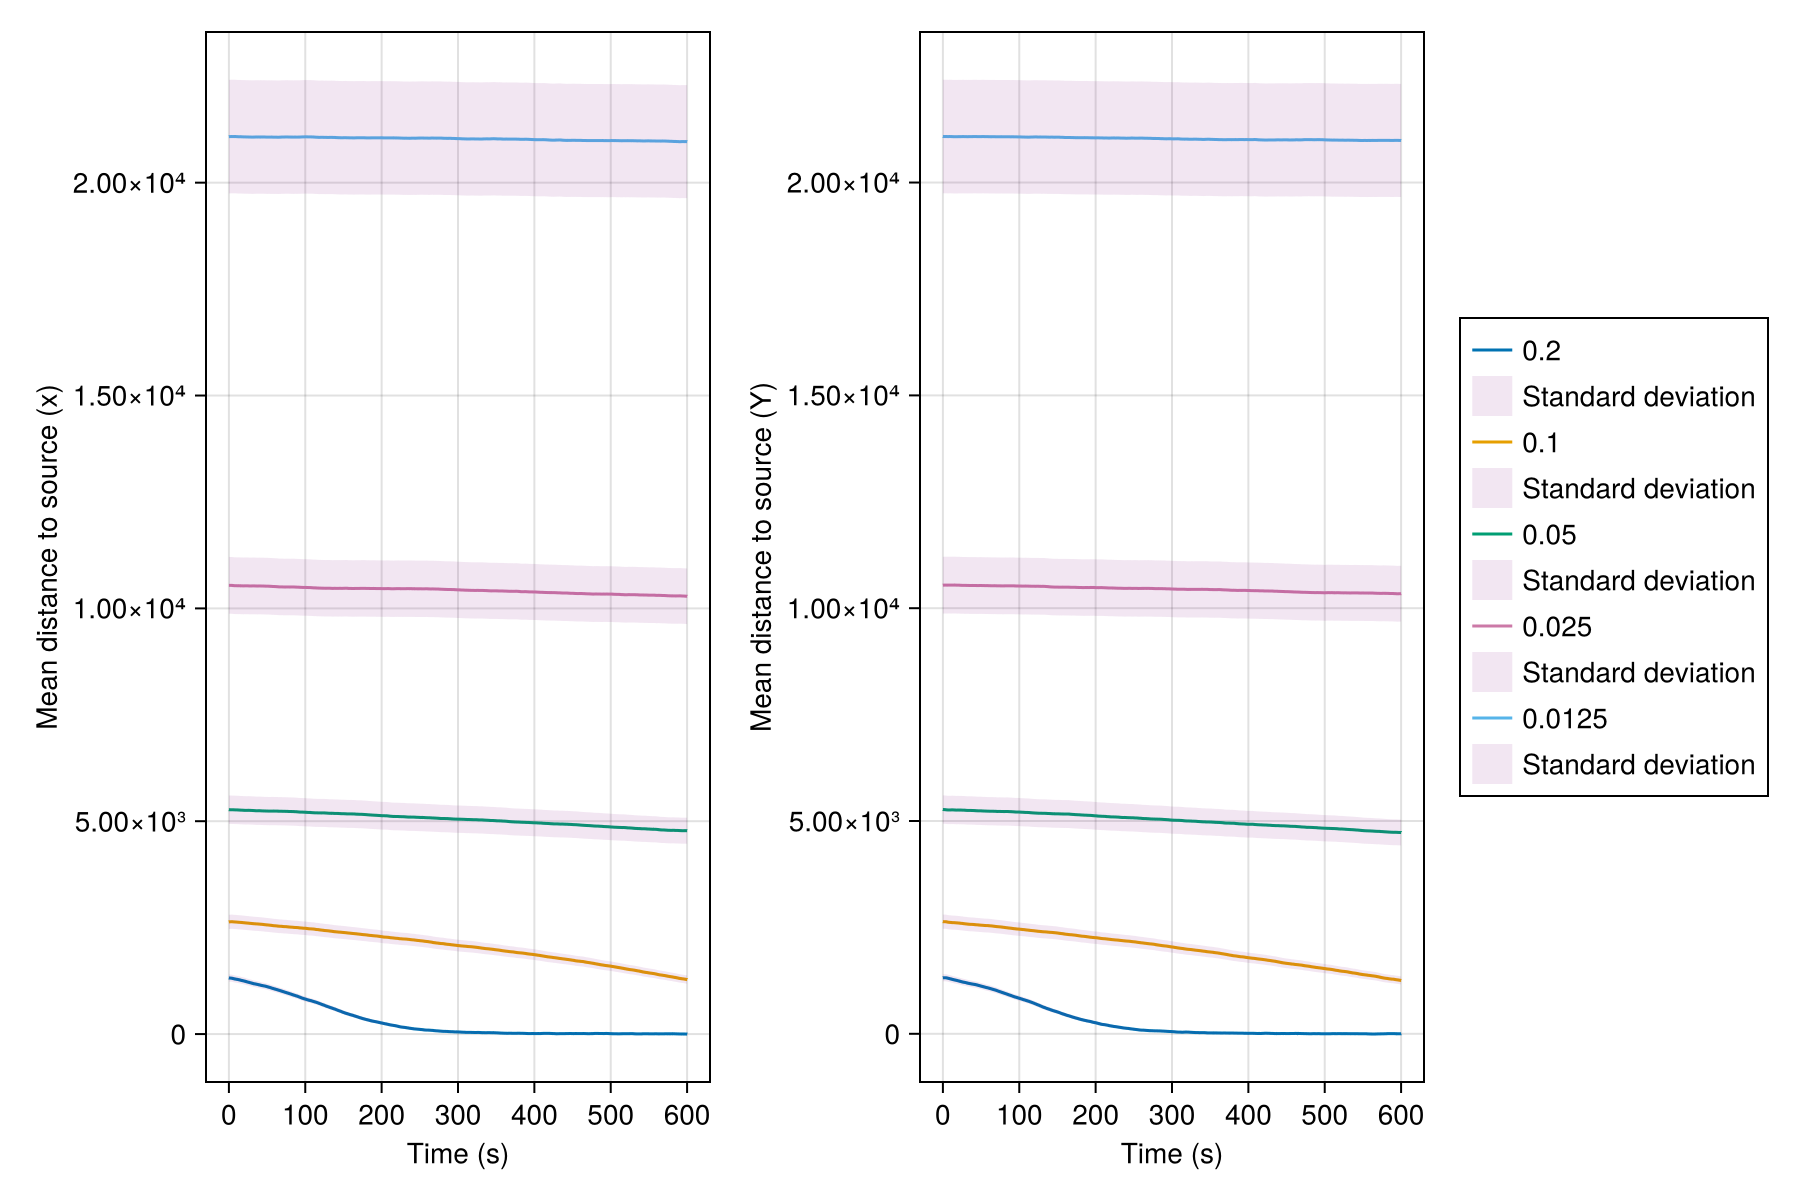

CairoMakie.Screen{IMAGE}


In [12]:
using CairoMakie
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source (x)")
ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 60000

v = [5, 10, 20, 50, 100]
ls = [0.2, 0.1, 0.05, 0.025, 0.0125]

for i in 1:length(ls)

    mean_dist_x = Float64[] 
    std_dist_x = Float64[]
    mean_dist_y = Float64[] 
    std_dist_y = Float64[]
    jldopen("fsb_v100.0_l$(ls[i])_k.jld2", "r") do file 

        for step in 1:steps
            g = file[@sprintf("step_%06d", step)]

            xs = 0
            ys = 0

            other_x = g["x"]

            other_y = g["y"]

            dists_x = other_x .- xs
            dists_y = other_y .- ys
            norm_x = dists_x
            norm_y = dists_y

            push!(mean_dist_x, mean(norm_x))
            push!(std_dist_x, std(norm_x))
            push!(mean_dist_y, mean(norm_y))
            push!(std_dist_y, std(norm_y))

        end

        std_X = std_dist_x ./ sqrt(500)
        std_Y = std_dist_y ./ sqrt(500)

        lines!(ax1, (1:steps)*0.01, mean_dist_x, label = "$(ls[i])")
        band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.1), label = "Standard deviation")
        
        lines!(ax2, (1:steps)*0.01, mean_dist_y)
        band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.1), label = "Standard deviation") 

    end
end
fig3[1,3] = Legend(fig3, ax1) 

display(fig3)

In [13]:
CairoMakie.save("Plots/Fixed_source_model/Next/n_small_v100_k.svg", fig3)

CairoMakie.Screen{SVG}


In [93]:
dfs_lambda = Dict{Float64, DataFrame}()


# vel = [10.0, 20.0, 50.0, 100.0]
lambdas = [0.2, 0.1]
N_agents = 500
end_step = 60000

for (l_idx, l) in enumerate(lambdas)

    filename = @sprintf("fsb_v10.0_l%s_k.jld2", l)
    println("Processing $filename")

        # -----------------------------
        # STEP 2: extract trajectories
        # -----------------------------
    steps_vec = Int[]
    agents_vec = Int[]
    x_vec = Float64[]
    y_vec = Float64[]
        
    jldopen(filename, "r") do file
        for agent in 1:500
            for step in 1:10:end_step
                g = file[@sprintf("step_%06d", step)]

                push!(steps_vec, step)
                push!(agents_vec, agent)
                push!(x_vec, g["x"][agent])
                push!(y_vec, g["y"][agent])
            end
        end
    end

    df = DataFrame(
        step = steps_vec,
        agent = agents_vec,
        x = x_vec,
        y = y_vec
    )

        # store in dict
    dfs_lambda[l] = df

end

Processing fsb_v10.0_l0.2_k.jld2
Processing fsb_v10.0_l0.1_k.jld2


In [ ]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

In [203]:
times = zeros(2, 2)
times[:, 1] = [0.2, 0.1]
times[:, 2] = [40000, 50000]

2-element Vector{Int64}:
 40000
 50000

In [211]:
metrics_test = DataFrame(
    l = Float64[],
    mu_x = Float64[],
    mu_y = Float64[],
    sigma = Float64[],
    k = Float64[],
    D = Float64[]
)

lambdas = [0.1, 0.2]

for i in 1:2
    df = dfs_lambda[lambdas[i]]

    eq_step = times[i, 2]

    eq = df[df.step .>= eq_step, :]

    mu_x = mean(eq.x)
    mu_y = mean(eq.y)
    sigma_x = std(eq.x)
    sigma_y = std(eq.y)

    sigma = (sigma_x + sigma_y) / 2

    grouped_ag = groupby(eq, :agent)
    lags = (1:50:400)

    correlations = zeros(length(grouped_ag), length(lags))
    correlations_y = zeros(length(grouped_ag), length(lags))

    for i in 1:length(grouped_ag)
        df_ag = grouped_ag[i]
        traj = df_ag.x
        traj_y = df_ag.y
        cor = autocor(traj, lags; demean = false)
        cor_y = autocor(traj_y, lags; demean = false)
        correlations[i, :] = cor
        correlations_y[i, :] = cor_y
    end

    correlations_mean = Float64[]
    correlations_mean_y = Float64[]

    for i in 1:length(lags)
        lag_mean = correlations[:, i]
        lag_mean_y = correlations_y[:, i]
        push!(correlations_mean, mean(lag_mean))
        push!(correlations_mean_y, mean(lag_mean_y))
    end

    logx = log.(abs.(correlations_mean))
    logy = log.(abs.(correlations_mean_y))

    slope_x, intercept_x = linear_fit(lags, logx)
    slope_y, intercept_y = linear_fit(lags, logy)
    k_x = -slope_x 
    k_y = -slope_y

    k = (k_x + k_y) / 2
    D = sigma^2 * k

    push!(metrics_test, (
        lambdas[i],
        mu_x,
        mu_y,
        sigma,
        k,
        D
    ))
end

In [100]:
@load "metrics_redo.jld2" metrics_redo

1-element Vector{Symbol}:
 :metrics_redo

In [212]:
metrics_test

Row,l,mu_x,mu_y,sigma,k,D
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.1,451.459,450.054,201.736,0.000658342,26.7928
2,0.2,0.295632,0.413672,17.0631,0.0158654,4.61922


In [197]:
metrics_lambdas

Row,l,mu_x,mu_y,sigma,k,D
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.2,0.917409,0.802124,20.6406,0.002385,1.01609
2,0.1,451.459,450.054,201.736,0.00145448,59.1934
3,0.1,407.776,408.319,207.558,0.0026802,115.464
4,0.1,407.776,408.319,207.558,0.0014883,64.1167


In [263]:
mask = (metrics_redo.v .== 10.0)
rows = metrics_redo[metrics_redo.v .== 10.0, :]
k = rows.k
lambdas = rows.lambda
push!(lambdas, 0.2)
push!(lambdas, 0.1)
push!(k, metrics_lambdas.k[1])
push!(k, metrics_lambdas.k[4])

15-element Vector{Float64}:
 0.014700701102237491
 0.010411796402124526
 0.006975835388149694
 0.012426053084010211
 0.016752444079465863
 0.014992132613218828
 0.016404874830912797
 0.016187336745849972
 0.015139815847446357
 0.01364877595912192
 0.002979615371731687
 0.018090994704881614
 0.01608258851939039
 0.0023850022737745957
 0.001488302373482326

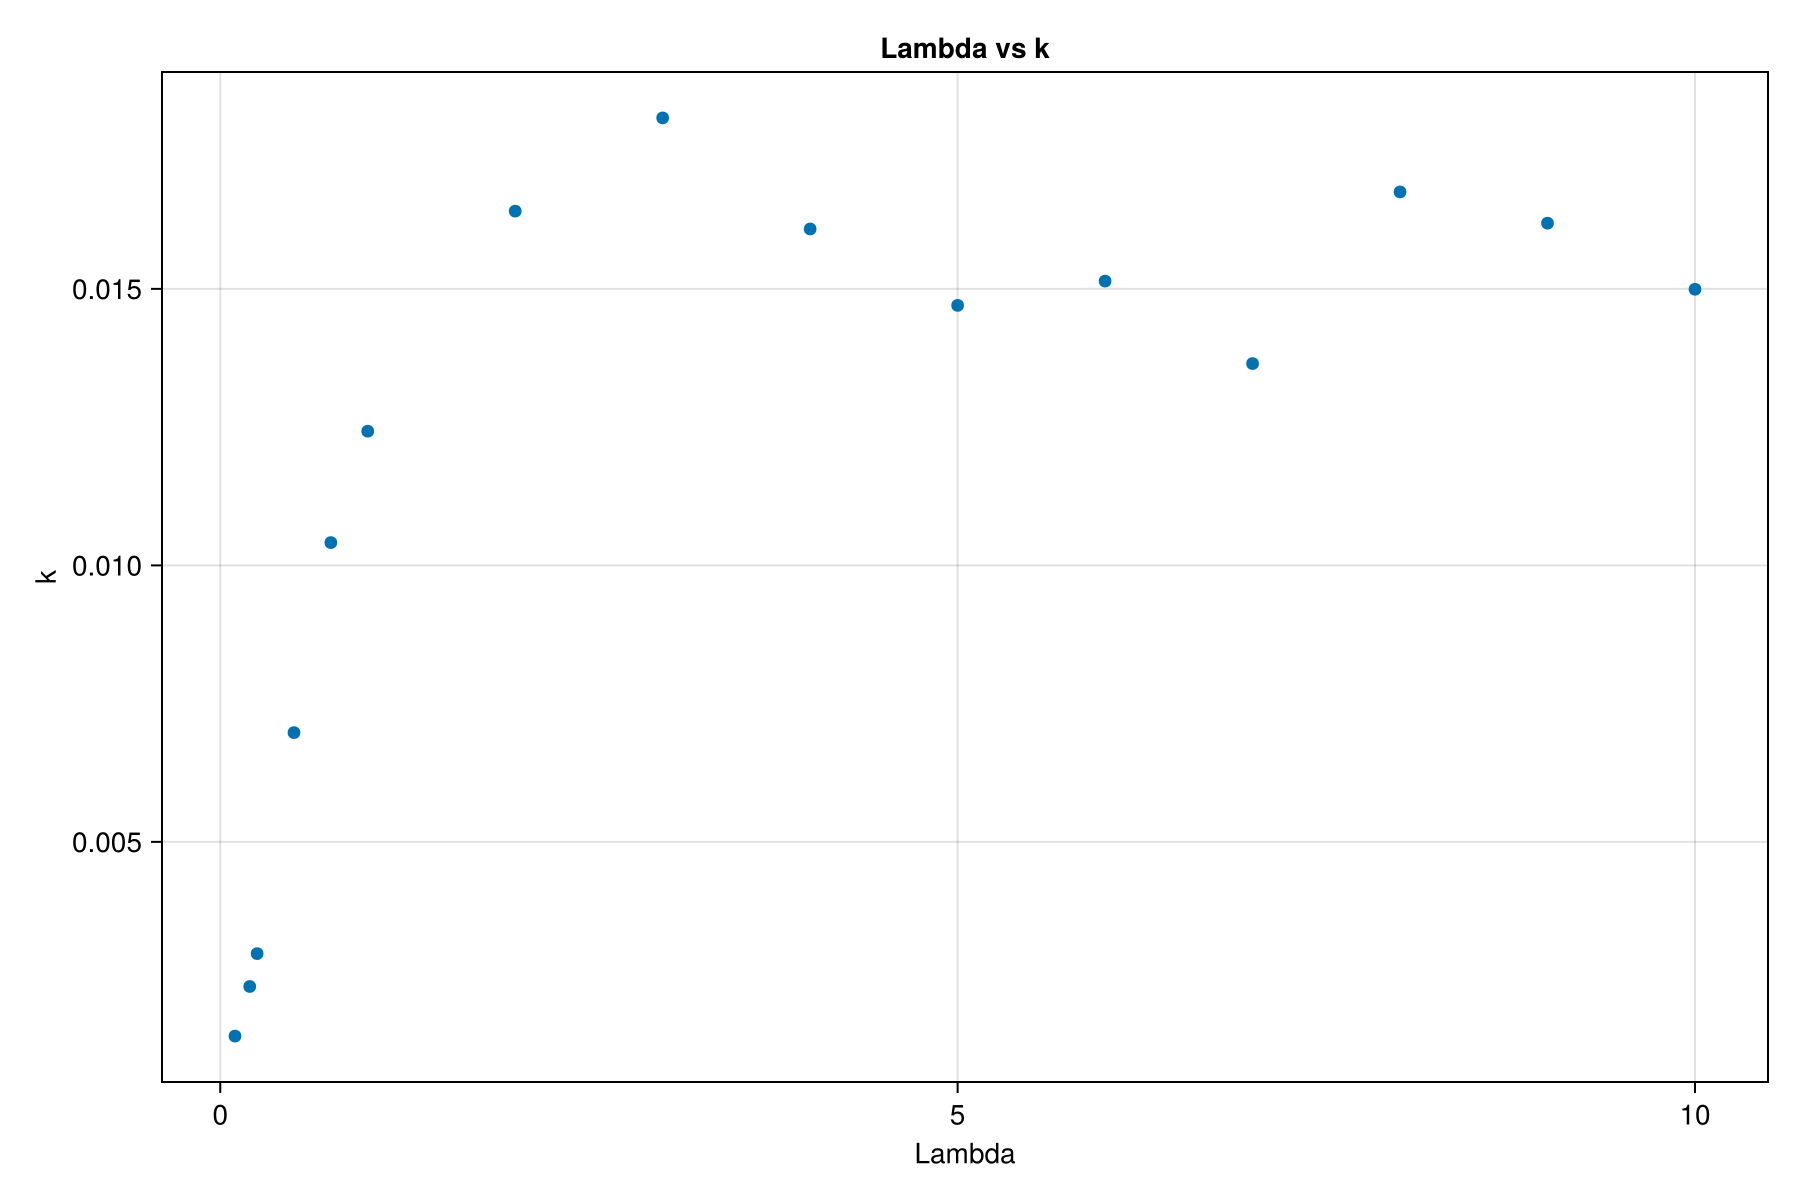

In [264]:
fig5 = Figure(size=(900, 600))
ax5 = Axis(fig5[1,1], title = "Lambda vs k", xlabel = "Lambda", ylabel = "k")
scatter!(ax5, lambdas, k)
fig5

In [258]:
save("Plots/Fixed_source_model/Next/n_small_v10_k_plot.svg", fig5)

CairoMakie.Screen{SVG}


In [271]:
ordered_k = sort(k)
first_k = ordered_k[1:6]
ordered_l = sort(lambdas)
first_l = ordered_l[1:6]

6-element Vector{Float64}:
 0.1
 0.2
 0.25
 0.5
 0.75
 1.0

0.01290965552213548 8.659490521561723e-5


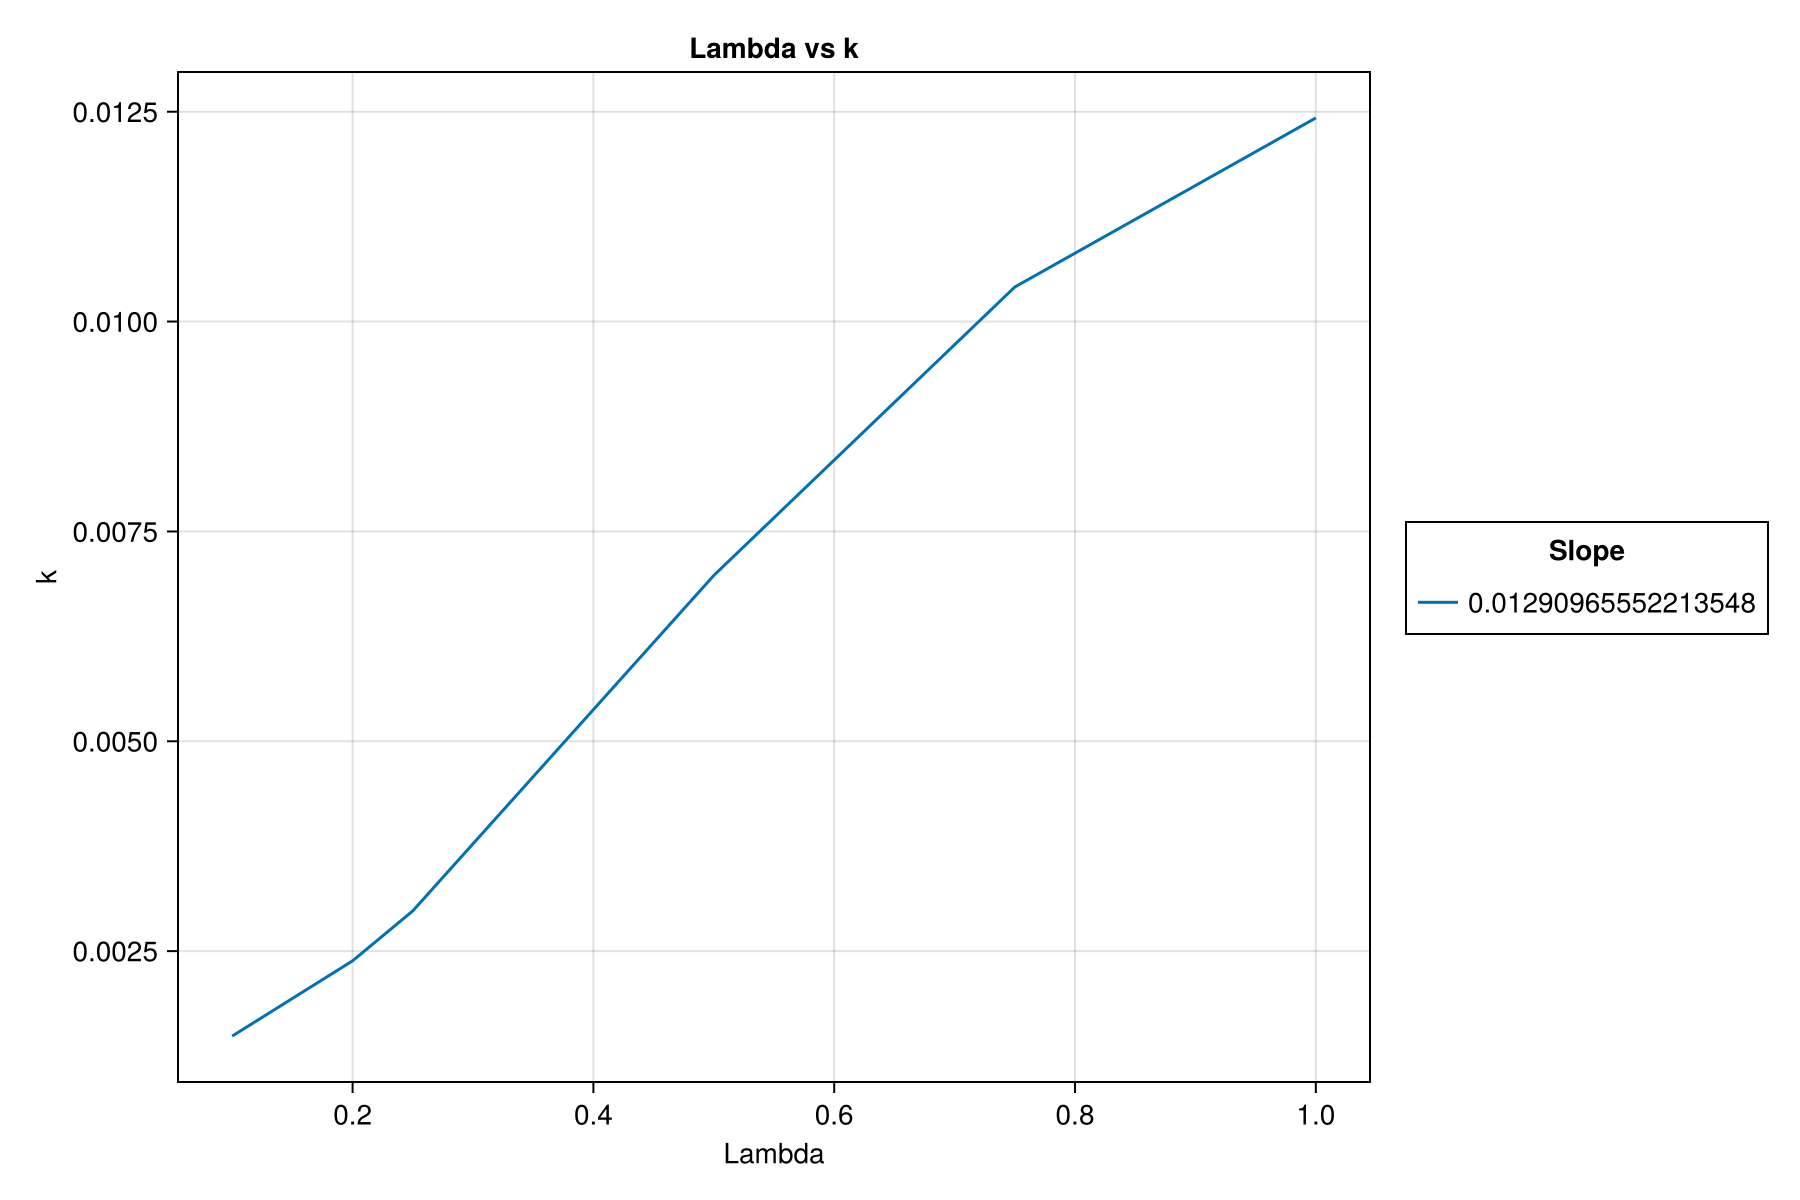

In [274]:
fig5 = Figure(size=(900, 600))
ax5 = Axis(fig5[1,1], title = "Lambda vs k", xlabel = "Lambda", ylabel = "k")
df = DataFrame(x = first_l, y = first_k)
model = lm(@formula(y ~ x), df)

a = coef(model)[2]   # slope
b = coef(model)[1]

lines!(ax5, first_l, first_k, label ="$a")


println(a, " ", b)
fig5[1,2] = Legend(fig5, ax5, "Slope")
fig5

In [275]:
save("Plots/Fixed_source_model/Next/small_lambdas_linear_fit.svg", fig5)

CairoMakie.Screen{SVG}


In [273]:
model

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

y ~ 1 + x

Coefficients:
───────────────────────────────────────────────────────────────────────────────
                  Coef.   Std. Error      t  Pr(>|t|)     Lower 95%   Upper 95%
───────────────────────────────────────────────────────────────────────────────
(Intercept)  8.65949e-5  0.000383147   0.23    0.8323  -0.000977191  0.00115038
x            0.0129097   0.000676434  19.08    <1e-04   0.0110316    0.0147877
───────────────────────────────────────────────────────────────────────────────

# Fields

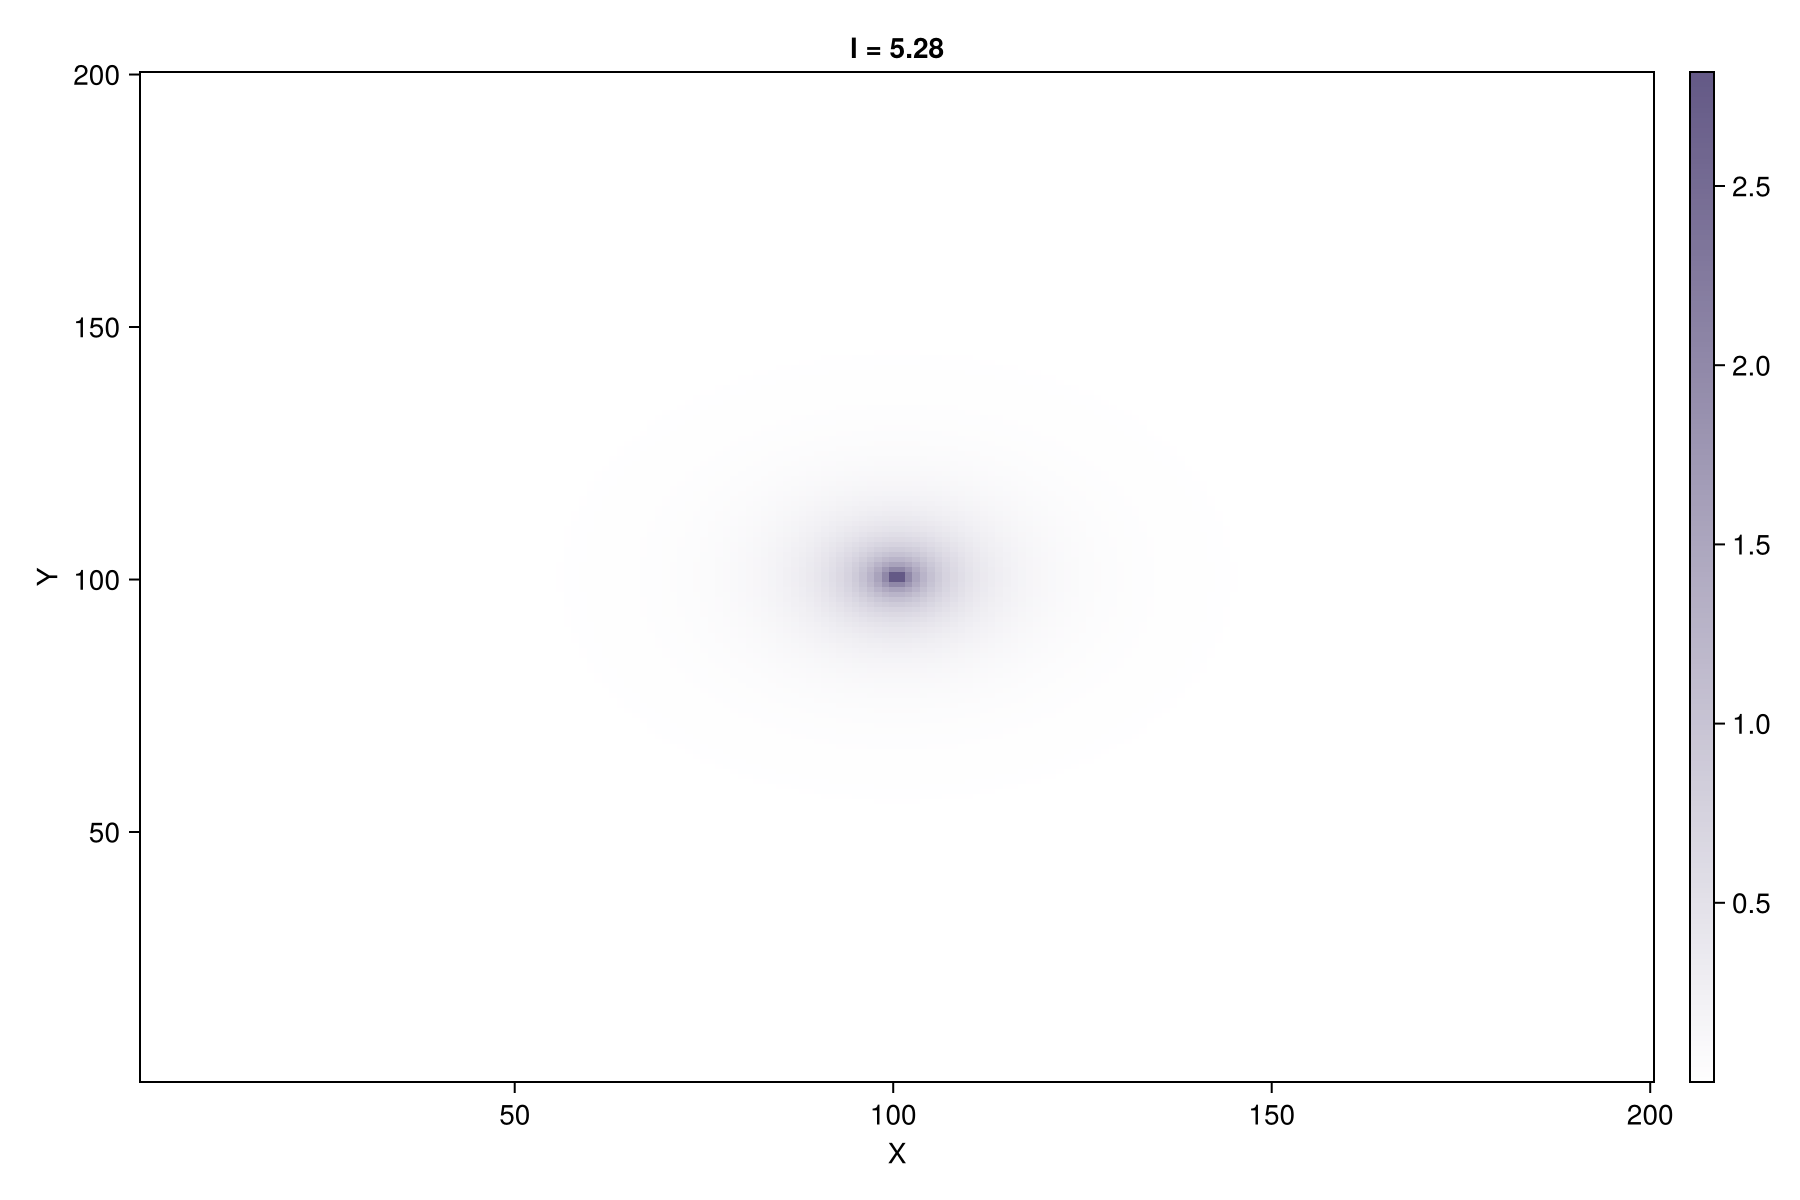

In [88]:
dark = colorant"#645986"
light = colorant"#F2EEF9"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark])
xs, ys = 0.0, 0.0
len = 200

x_grid = range(-50, 50, length=len)
y_grid = range(-50, 50, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(1.67 / 0.06)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

fig2 = Figure(size=(900, 600))
ax2 = Axis(fig2[1,1], title = "l = $(round(λ, digits = 2))", xlabel = "X", ylabel = "Y")
hm = heatmap!(ax2, mm_grid, colormap = cmap)
Colorbar(fig2[1,2], hm, colorrange = (0,5))
# xlims!(50, 150)
# ylims!(50, 150)
fig2

In [89]:
save("Plots/Fixed_source_model/Next/l_field_n6.svg", fig2)

CairoMakie.Screen{SVG}
